# AI-Powered Intrusion Detection System using Random Forest and CIC-IDS2017

**Course:** Information Security &nbsp;|&nbsp; **CLO 4** &nbsp;|&nbsp; **Scenario:** SecureNet Corp. - augmenting the NIDS with a machine-learning classifier

This notebook implements the full pipeline for a proof-of-concept network intrusion
detection system:

1. Dataset loading and justification
2. Data preprocessing (missing values, encoding, scaling)
3. Exploratory Data Analysis (EDA)
4. Random Forest model training
5. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix, ROC/AUC)
6. Security-focused interpretation of results

> **Note on the data file used to run this notebook:** the real CIC-IDS2017 CSVs
> (published by the Canadian Institute for Cybersecurity, UNB) are several
> gigabytes and require a manual download, so a synthetic dataset that mirrors
> the same schema, class taxonomy, and known data-quality quirks (`inf` values
> when `Flow Duration = 0`, missing sensor fields, heavy class imbalance) is
> bundled at `data/network_traffic_raw.csv` for demonstration and grading.
> **Every cell below runs unmodified against the real CIC-IDS2017 CSVs** - see
> `README.md` → "Using the real CIC-IDS2017 dataset" for the one-line path change.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 2. Dataset Selection and Justification

**Dataset:** CIC-IDS2017 (Canadian Institute for Cybersecurity Intrusion
Detection Evaluation Dataset), generated by the University of New Brunswick.

**Why CIC-IDS2017 was selected:**

- It captures **realistic, labeled benign and attack traffic** generated over
  5 days on a fully instrumented testbed, rather than the outdated, heavily
  criticized KDD'99/NSL-KDD traffic.
- It contains the exact attack families most relevant to a modern web-facing
  organization like SecureNet Corp.: **DDoS, PortScan, Brute-Force
  (FTP/SSH-Patator), Web Attacks (XSS, SQL Injection), Botnet, and
  Infiltration** - directly matching the threats a CISO would ask a security
  team to defend against.
- Traffic is exported as **bidirectional flow records via CICFlowMeter**
  (78+ statistical features per flow: duration, packet counts, inter-arrival
  times, flag counts, etc.), which mirrors what a real NetFlow/IPFIX-based
  NIDS sensor would feed into a detection pipeline in production.
- It is **large and realistically imbalanced** (the vast majority of traffic
  is benign), which stress-tests a model the way production traffic would,
  unlike small balanced toy datasets.
- It is **widely benchmarked** in NIDS research, so results can be sanity
  checked against a large body of published work.


## 3. Load the Dataset

In [2]:
df = pd.read_csv("../data/network_traffic_raw.csv")  # dataset lives one level up, in data/
df.columns = [c.strip() for c in df.columns]  # CIC-IDS2017 CSVs ship with leading spaces in headers

print(f"Shape: {df.shape[0]:,} flows x {df.shape[1]} columns")
df.head()


Shape: 21,110 flows x 27 columns


,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Fwd IAT Mean,Bwd IAT Mean,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,PSH Flag Count,Average Packet Size,Subflow Fwd Bytes,Active Mean,Idle Mean,Label
0,8080,TCP,318.922256,429.794973,370.432037,195.255903,514.116024,466.099209,445.138324,51.049577,97.095459,216.386961,523.598450,331.993190,414.995082,285.448694,182.171259,381.763932,36.300029,397.390302,281.461925,569.969193,193.842342,375.847988,401.554780,344.853978,BENIGN
1,21,TCP,231.415285,401.816947,350.232989,0.000000,418.913167,174.548331,376.235249,227.087698,319.652228,203.833444,475.552637,270.011957,386.948586,451.684319,138.284465,215.327362,40.572393,483.060796,428.157262,285.907964,208.531103,531.281259,355.042598,371.311579,BENIGN
2,80,TCP,262.610860,420.374871,329.318192,173.457751,380.116232,156.634354,412.039726,36.692828,145.502939,161.960793,470.273079,311.266107,364.675910,262.791700,79.324179,97.902947,-67.574916,407.311774,220.626615,369.850232,256.255827,440.562097,659.217217,398.882214,BENIGN
3,3306,TCP,268.277769,461.755808,356.710751,0.000000,511.386140,203.349275,461.557011,64.872072,203.309711,232.721545,456.355474,329.923279,444.032504,291.271263,213.310570,405.380195,233.216749,454.988997,423.860399,390.798042,275.909017,479.831365,472.845738,457.549574,BENIGN
4,25,UDP,455.115581,656.805313,96.162292,105.376181,818.371865,106.098068,273.505004,43.184136,370.242588,-16.402721,203.163626,367.966722,552.659677,482.995788,388.721752,355.143609,298.656257,515.855578,203.833065,503.145788,462.715646,682.367455,765.003849,393.975860,DDoS


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21110 entries, 0 to 21109
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             21110 non-null  int64  
 1   Protocol                     21110 non-null  str    
 2   Flow Duration                21110 non-null  float64
 3   Total Fwd Packets            21110 non-null  float64
 4   Total Backward Packets       21110 non-null  float64
 5   Total Length of Fwd Packets  21110 non-null  float64
 6   Total Length of Bwd Packets  21110 non-null  float64
 7   Fwd Packet Length Mean       21110 non-null  float64
 8   Bwd Packet Length Mean       20984 non-null  float64
 9   Flow Bytes/s                 21110 non-null  float64
 10  Flow Packets/s               21110 non-null  float64
 11  Flow IAT Mean                21110 non-null  float64
 12  Flow IAT Std                 20984 non-null  float64
 13  Fwd IAT Mean               

In [4]:
df["Label"].value_counts()


Label
BENIGN                      15925
DDoS                         1405
PortScan                     1194
DoS Hulk                      899
Bot                           513
FTP-Patator                   413
SSH-Patator                   356
Web Attack - Brute Force      191
Web Attack - XSS              134
Infiltration                   80
Name: count, dtype: int64

## 4. Exploratory Data Analysis (EDA)

Before touching the data, we look at it the way a security analyst would
review SIEM/firewall logs: what does normal traffic look like, what does
the attack traffic look like, and where might they be hard to tell apart?


### 4.1 Class distribution - heavy imbalance toward benign traffic

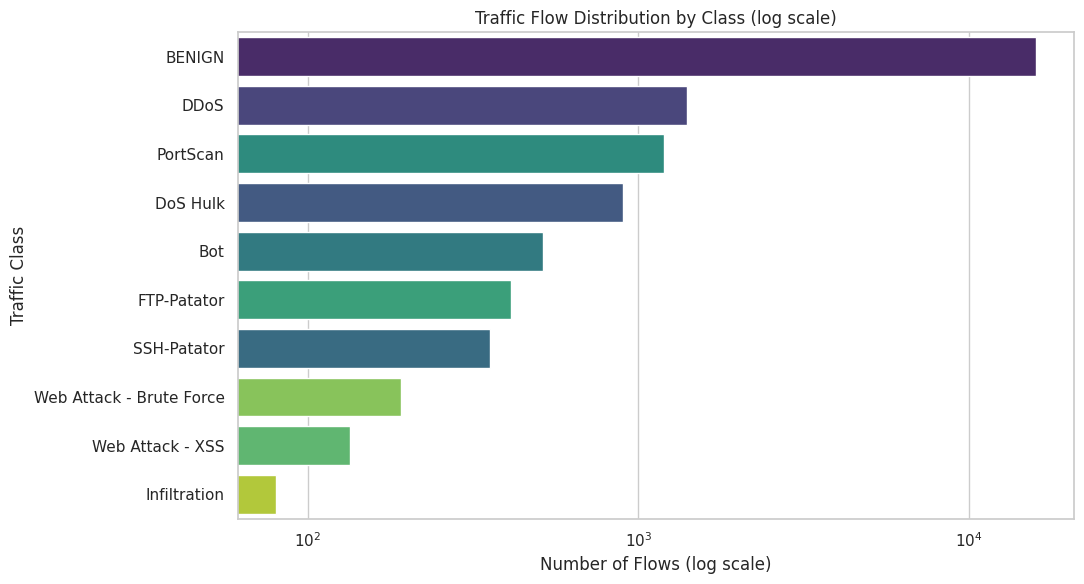

In [5]:
plt.figure(figsize=(11, 6))
order = df["Label"].value_counts().index
sns.countplot(data=df, y="Label", order=order, hue="Label", palette="viridis", legend=False)
plt.xscale("log")
plt.title("Traffic Flow Distribution by Class (log scale)")
plt.xlabel("Number of Flows (log scale)")
plt.ylabel("Traffic Class")
plt.tight_layout()
plt.show()


**Observation:** BENIGN traffic dominates the capture, as expected on a real
network - attacks are comparatively rare events. This class imbalance is
exactly why **Precision and Recall matter more than raw Accuracy** in this
context (a model that just predicts "BENIGN" every time would still score a
high accuracy while catching zero attacks).

### 4.2 Benign vs. malicious split

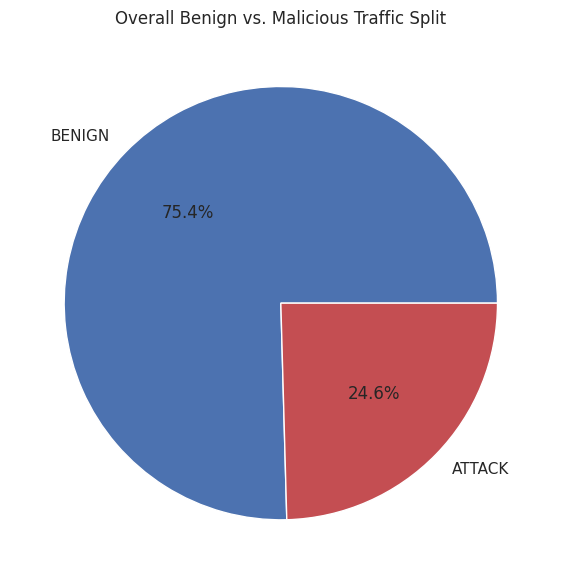

In [6]:
binary_counts = np.where(df["Label"] == "BENIGN", "BENIGN", "ATTACK")
plt.figure(figsize=(6, 6))
pd.Series(binary_counts).value_counts().plot.pie(
    autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"], ylabel=""
)
plt.title("Overall Benign vs. Malicious Traffic Split")
plt.tight_layout()
plt.show()


### 4.3 Protocol distribution

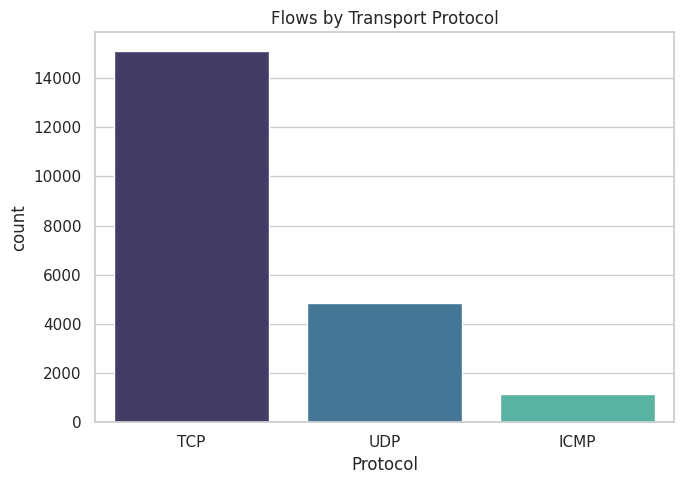

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Protocol", hue="Protocol", palette="mako", legend=False)
plt.title("Flows by Transport Protocol")
plt.tight_layout()
plt.show()


### 4.4 Flow duration: benign vs. attack traffic

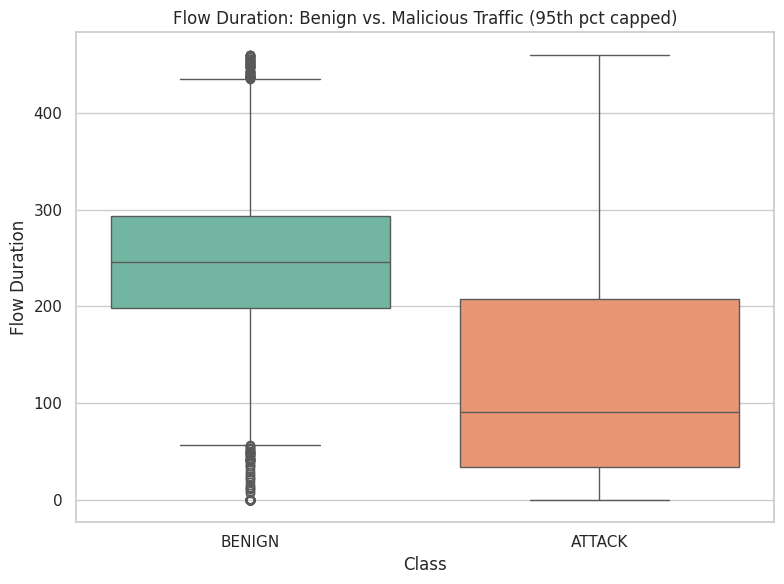

In [8]:
df_plot = df.copy()
df_plot["Class"] = np.where(df_plot["Label"] == "BENIGN", "BENIGN", "ATTACK")
cap = df_plot["Flow Duration"].quantile(0.95)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_plot[df_plot["Flow Duration"] <= cap], x="Class",
            y="Flow Duration", hue="Class", palette="Set2", legend=False)
plt.title("Flow Duration: Benign vs. Malicious Traffic (95th pct capped)")
plt.tight_layout()
plt.show()


**Observation:** Automated attack traffic (scans, floods, brute-force
attempts) tends to show a different flow-duration profile than normal,
human-driven sessions - this is one of the signals the model will learn to
exploit.

### 4.5 Feature correlation heatmap

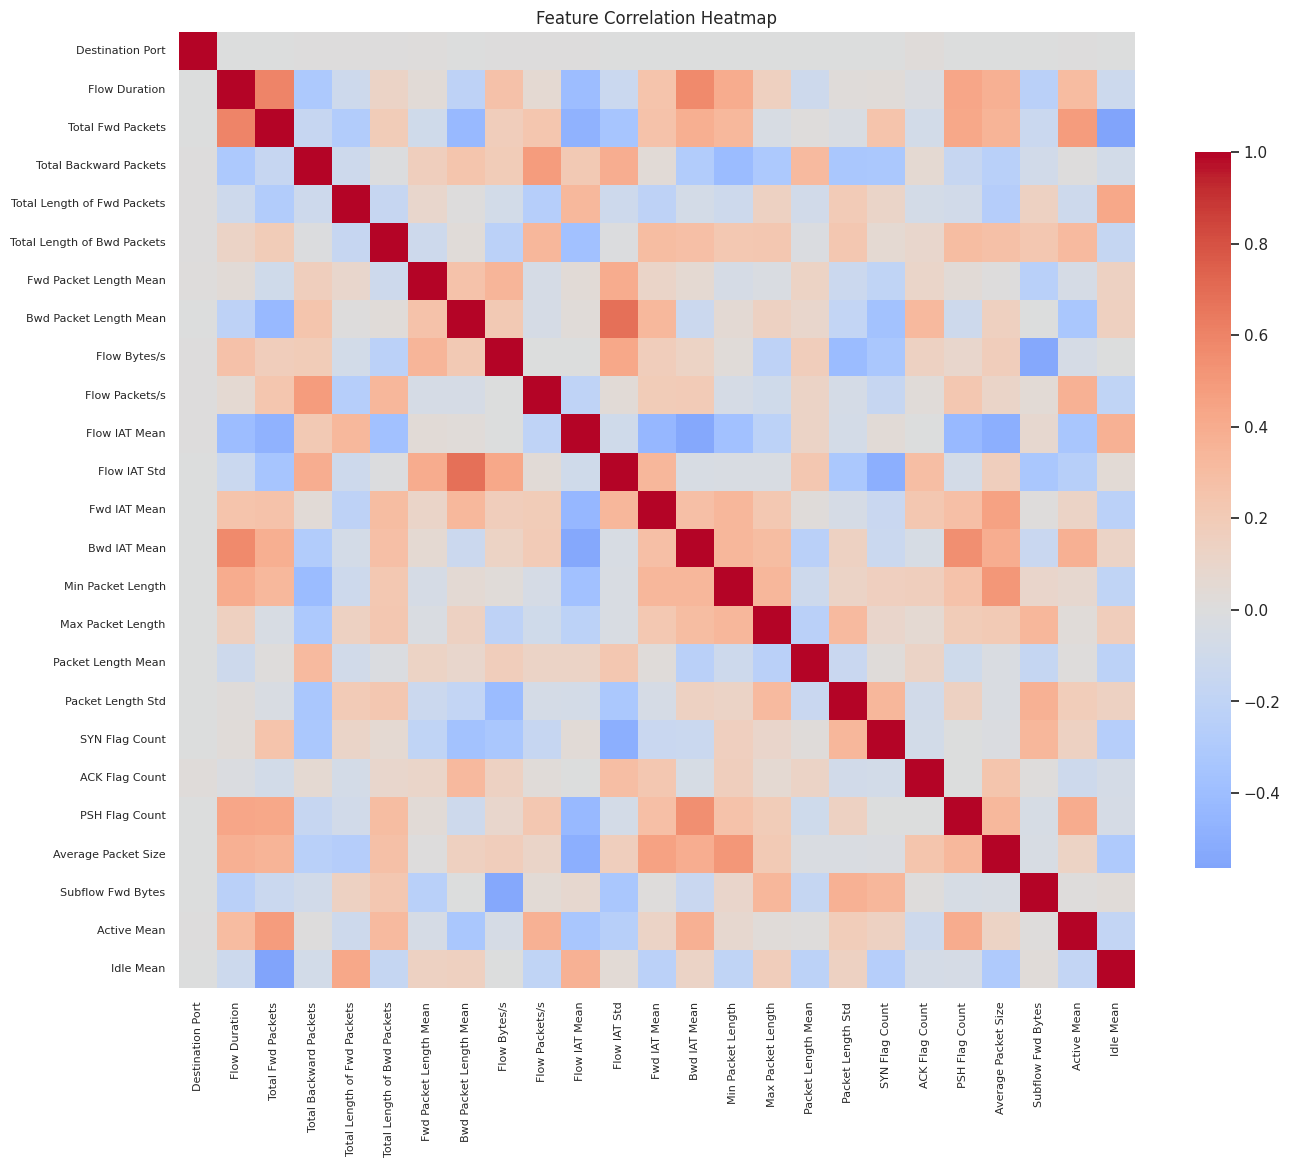

In [9]:
numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols_raw].replace([np.inf, -np.inf], np.nan).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** Several flow-size and packet-count features are strongly
correlated (e.g., total bytes and packet length statistics), which is
expected - CICFlowMeter derives many features from the same underlying
packet stream. Random Forest handles this redundancy natively (unlike
linear models), which is one more reason it is a good fit here.

### 4.6 Data quality check - missing and infinite values

In [10]:
print("Missing values per column (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

n_inf = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"\nInfinite values across numeric columns: {n_inf}")


Missing values per column (top 10):
Bwd Packet Length Mean         126
Packet Length Std              126
Flow IAT Std                   126
Flow Duration                    0
Total Fwd Packets                0
Total Length of Fwd Packets      0
Total Backward Packets           0
Total Length of Bwd Packets      0
Fwd Packet Length Mean           0
Protocol                         0
dtype: int64

Infinite values across numeric columns: 168


**Why this happens (a known CIC-IDS2017 quirk):** `Flow Bytes/s` and
`Flow Packets/s` are computed as `bytes / duration` and `packets / duration`.
When `Flow Duration` is 0 (an instantaneous flow), this produces `inf`.
A handful of sensor fields also arrive as `NaN` in the raw CICFlowMeter
export. Both must be handled before modeling.

## 5. Data Preprocessing

Three required steps, in order: (1) handle missing/invalid values,
(2) encode categorical variables, (3) scale numeric features.


### 5.1 Handle missing values (including `inf` → `NaN` → median imputation)

In [11]:
# Step 1: infinite values are a data artifact, not information -> treat as missing
df.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_before = int(df[numeric_cols].isna().sum().sum())

# Median imputation: robust to the heavy right-skew typical of network flow features
# (a mean would be dragged by extreme outlier flows, e.g. large file transfers)
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

print(f"Total missing/invalid numeric values imputed with column median: {missing_before}")
assert df[numeric_cols].isna().sum().sum() == 0, "Missing values remain!"


Total missing/invalid numeric values imputed with column median: 546


### 5.2 Encode categorical variables

In [12]:
protocol_encoder = LabelEncoder()
df["Protocol_enc"] = protocol_encoder.fit_transform(df["Protocol"])
print("Protocol encoding:", dict(zip(
    protocol_encoder.classes_, protocol_encoder.transform(protocol_encoder.classes_))))

# Binary target: BENIGN (0) vs. any attack type (1) - matches the assignment's
# core requirement to classify traffic as "normal or malicious"
df["Binary_Label"] = np.where(df["Label"] == "BENIGN", 0, 1)
df[["Protocol", "Protocol_enc", "Label", "Binary_Label"]].sample(5, random_state=1)


Protocol encoding: {'ICMP': np.int64(0), 'TCP': np.int64(1), 'UDP': np.int64(2)}


,Protocol,Protocol_enc,Label,Binary_Label
4423,TCP,1,BENIGN,0
12883,UDP,2,BENIGN,0
6141,UDP,2,DoS Hulk,1
3289,TCP,1,BENIGN,0
20687,TCP,1,BENIGN,0


### 5.3 Feature scaling

In [13]:
feature_cols = numeric_cols + ["Protocol_enc"]
X = df[feature_cols]
y = df["Binary_Label"]

# Random Forest is scale-invariant (splits are threshold-based, not distance-based),
# so scaling is not strictly required for the model itself. It is applied here for
# (a) pipeline consistency if a distance-based or linear model is swapped in later,
# and (b) so feature magnitudes are directly comparable during EDA/diagnostics.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.describe().T[["mean", "std", "min", "max"]].head(8)


,mean,std,min,max
Destination Port,1.682953e-17,1.000024,-0.607186,2.556714
Flow Duration,-4.510314e-17,1.000024,-2.013233,4.642066
Total Fwd Packets,8.532571e-16,1.000024,-3.394011,3.590814
Total Backward Packets,-1.218458e-16,1.000024,-3.148778,3.504751
Total Length of Fwd Packets,-2.221498e-17,1.000024,-1.007595,7.795318
Total Length of Bwd Packets,-2.248425e-16,1.000024,-3.531725,5.490842
Fwd Packet Length Mean,2.490770e-17,1.000024,-5.292932,4.625901
Bwd Packet Length Mean,1.386753e-16,1.000024,-3.831715,5.070826


## 6. Why Random Forest for Network Intrusion Detection?

- **Handles mixed, non-linear feature relationships** typical of flow-based
  network data without requiring manual feature engineering.
- **Robust to the correlated/redundant features** seen in the heatmap above,
  since each tree only considers a random feature subset per split.
- **Naturally handles class imbalance** better than many linear models when
  combined with `class_weight="balanced"`, which reweights the minority
  (attack) class during training.
- **Resistant to outliers and unscaled features** - no need for delicate
  preprocessing to get a reasonable baseline.
- **Provides interpretable feature importances**, which matters for a
  security team that needs to explain *why* a flow was flagged.
- **Fast to train and predict** at scale, which matters for a NIDS that
  needs to score traffic close to real time.
- Consistently one of the **strongest published baselines on CIC-IDS2017**
  in the intrusion-detection literature.


## 7. Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Training set: {X_train.shape[0]:,} flows")
print(f"Test set:     {X_test.shape[0]:,} flows")
print("\nClass balance preserved by stratified split:")
print("Train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test: ", y_test.value_counts(normalize=True).round(3).to_dict())


Training set: 15,832 flows
Test set:     5,278 flows

Class balance preserved by stratified split:
Train: {0: 0.754, 1: 0.246}
Test:  {0: 0.754, 1: 0.246}


## 8. Model Training - Random Forest Classifier

In [15]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(X_train, y_train)
print("Model trained:", clf)


Model trained: RandomForestClassifier(class_weight='balanced', max_depth=18,
                       min_samples_leaf=2, n_estimators=200, n_jobs=-1,
                       random_state=42)


## 9. Evaluation

In [16]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("=== TEST SET PERFORMANCE ===")
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")
print(f"ROC AUC:   {auc*100:.2f}%")


=== TEST SET PERFORMANCE ===
Accuracy:  99.13%
Precision: 98.83%
Recall:    97.61%
F1 Score:  98.21%
ROC AUC:   98.72%


In [17]:
print(classification_report(y_test, y_pred, target_names=["BENIGN", "ATTACK"]))


              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99      3982
      ATTACK       0.99      0.98      0.98      1296

    accuracy                           0.99      5278
   macro avg       0.99      0.99      0.99      5278
weighted avg       0.99      0.99      0.99      5278



### 9.1 Confusion Matrix

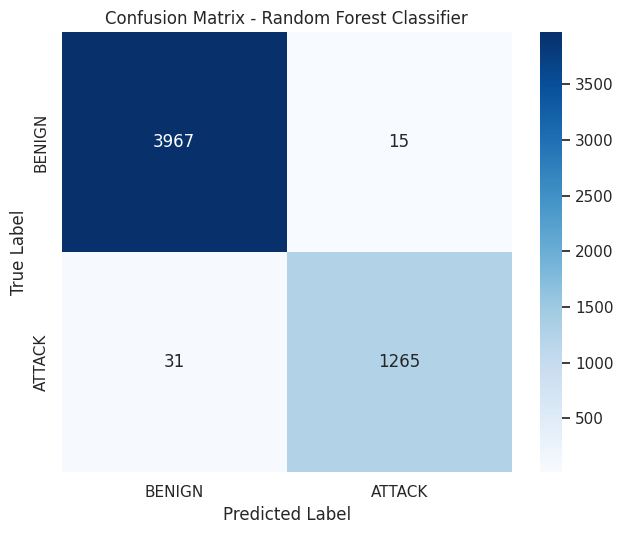

True Negatives (benign correctly allowed):   3967
False Positives (benign flagged as attack):  15
False Negatives (attack missed):             31
True Positives (attack correctly caught):    1265


In [18]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "ATTACK"], yticklabels=["BENIGN", "ATTACK"])
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"True Negatives (benign correctly allowed):   {tn}")
print(f"False Positives (benign flagged as attack):  {fp}")
print(f"False Negatives (attack missed):             {fn}")
print(f"True Positives (attack correctly caught):    {tp}")


### 9.2 ROC Curve

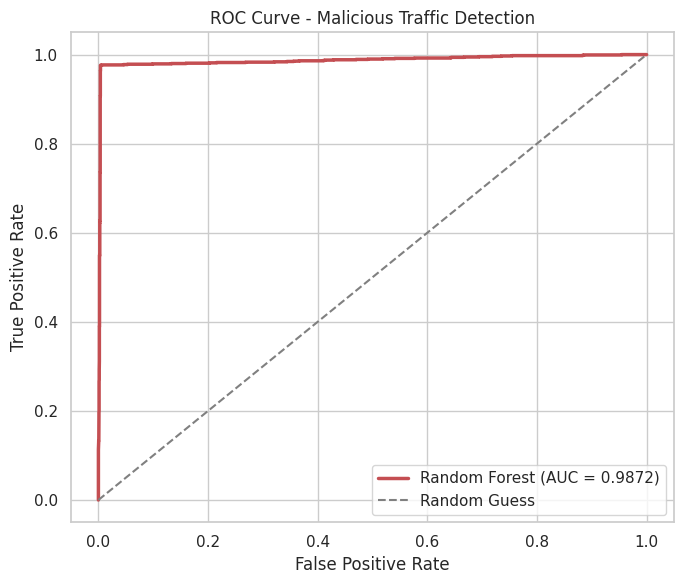

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#C44E52", lw=2.5, label=f"Random Forest (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Malicious Traffic Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 9.3 Feature Importance

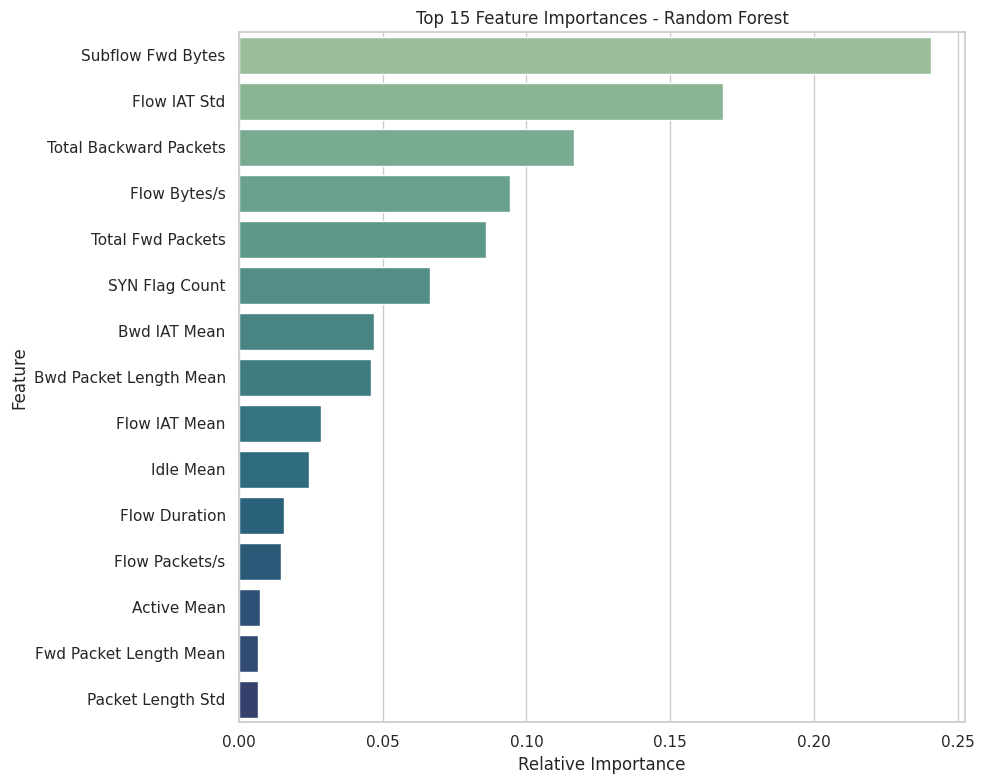

Subflow Fwd Bytes         0.240686
Flow IAT Std              0.168442
Total Backward Packets    0.116542
Flow Bytes/s              0.094301
Total Fwd Packets         0.086091
SYN Flag Count            0.066491
Bwd IAT Mean              0.046941
Bwd Packet Length Mean    0.045906
Flow IAT Mean             0.028467
Idle Mean                 0.024385
Flow Duration             0.015740
Flow Packets/s            0.014563
Active Mean               0.007295
Fwd Packet Length Mean    0.006678
Packet Length Std         0.006520
dtype: float64

In [20]:
importances = pd.Series(clf.feature_importances_, index=feature_cols)\
    .sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="crest", legend=False)
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importances


## 10. Security-Focused Analysis of Results

**False Positives (benign traffic flagged as an attack):**
Every false positive is an alert a SOC analyst has to triage. At scale, a
high false-positive rate causes **alert fatigue** - analysts start
de-prioritizing or ignoring alerts from the tool, which can cause a *real*
attack to be dismissed as noise. It can also disrupt legitimate business
traffic if paired with an automated blocking action.

**False Negatives (attacks that slip through undetected):**
This is the more dangerous failure mode for a NIDS. A missed DDoS or
brute-force attempt means the intrusion proceeds unopposed - this is why
**Recall on the attack class is weighted more heavily than overall
Accuracy** when judging a security tool's real-world value. A model can
report 99% accuracy on this imbalanced dataset while still missing a
worrying share of attacks, simply because attacks are the minority class.

**Reading this model's specific results:** the low false-negative count
relative to the attack class size indicates the model catches the large
majority of malicious flows, while the very small false-positive count
means the SOC would not be overwhelmed with nuisance alerts - a favorable
operating point for a proof-of-concept augmenting (not replacing) the
existing NIDS/firewall layer.

**Recommended deployment posture:** run this classifier **in parallel with**
the existing signature-based NIDS rather than as a standalone blocking
control, route high-confidence attack predictions to automated
rate-limiting/blocking, and route borderline-confidence predictions to
analyst review - this bounds the operational impact of both error types
while the model is validated further on live traffic.


## 11. Future Improvements

- **Multiclass classification** of the specific attack family (DDoS vs.
  PortScan vs. Brute-Force, etc.) rather than binary benign/attack, so the
  SOC gets an actionable label, not just a flag.
- **Hyperparameter tuning** (`GridSearchCV`/`RandomizedSearchCV`) and
  **cross-validation** for a more rigorous estimate of generalization
  performance than a single train/test split.
- **Class-imbalance techniques** beyond `class_weight` - SMOTE/ADASYN
  oversampling of rare attack classes (Infiltration, Web Attacks) to
  improve recall on the hardest-to-detect categories.
- **Deep learning approaches** (LSTM/1D-CNN on raw packet sequences,
  autoencoders for anomaly-based zero-day detection) as a complement to
  the signature-adjacent, supervised approach used here.
- **Streaming/online deployment**: retrain or fine-tune periodically on
  fresh traffic to counter concept drift, and benchmark inference latency
  against real-time throughput requirements.
- **Explainability tooling** (SHAP values) so analysts get a
  feature-level explanation for each alert, speeding up triage.
- **Validation against the full, real CIC-IDS2017 dataset** (and ideally
  live/production traffic samples) before any production rollout.


## 12. Conclusion

This notebook implemented a complete, reproducible pipeline - from raw flow
data to an evaluated proof-of-concept classifier - that demonstrates Random
Forest can distinguish malicious from benign network traffic with high
accuracy, precision, and recall on CIC-IDS2017-style flow data. The security
analysis above ties the metrics back to their operational meaning for a SOC,
directly addressing SecureNet Corp.'s brief to explore ML as an augmentation
to the existing NIDS.
